# Predicting High and Low Corvus corone Observation Activity

## A.S.K
- Matin
- Mohamad
- Dima

----

# 1. Business Understanding

Corvus corone, known as the Carrion Crow, is a black bird found across many parts 
of Europe, including the Netherlands. These birds are commonly found in parks, 
farms, and cities, where they feed on insects, seeds, fruit, and small animals. 
Corvus corone can live for around 10 years in the wild. They are considered highly 
intelligent birds, capable of recognizing human faces and solving simple problems. 
Because of this, Corvus corone is one of the most commonly observed and recognized 
bird species among citizen scientists.

## 1.1 Problem description


Large amounts of citizen-science data about Corvus corone are available through 
biodiversity observation platforms. These datasets contain valuable information 
about when and where observations are reported across different locations and 
time periods. However, the distribution of observations is highly uneven. Some 
locations and periods contain many observations, while others contain very few.

Observation activity may be influenced by several factors, including weather 
conditions, seasonal changes, geographic location, and human observation behavior. 
Because the dataset is based on citizen-science reports, individual observations 
may be noisy and influenced by reporting effort.

Currently, there is no simple method for estimating when and where high Corvus 
corone observation activity is likely to occur. A predictive model may help 
identify patterns in observation activity and improve understanding of how 
environmental and temporal factors influence citizen-science reporting data.

## 1.2 Business objective

The business objective of this project is to understand which factors affect 
Corvus corone observation activity. By analyzing variables such as temperature, 
season, and location, the project aims to identify patterns in crow observations 
and determine whether these factors affect observation activity. The findings may 
also support citizen science initiatives and biodiversity monitoring efforts.

Business Success Criteria
This project will be considered successful if clear relationships between Corvus 
corone observation activity and the selected variables (temperature, season, and 
location) can be identified. In addition, the results should provide useful 
insights that can support future biodiversity monitoring and citizen science 
projects.

## 1.3 Data Mining Goal (DMG)

The data mining goal of this project is to build and evaluate a binary 
classification model that predicts whether Corvus corone observation activity 
will be high or low for a given location and time period. In addition, the 
project aims to analyse the relationship between observation activity and 
factors such as temperature, season, and location in order to identify which 
variables have the strongest effect on observation activity.

The model will use spatial, temporal, and weather-related variables as input 
features. These may include location information, season, temperature, rainfall, 
humidity, and wind speed.

The target variable represents the level of Corvus corone observation activity:

- 0 = low Corvus corone observation activity
- 1 = high Corvus corone observation activity

To make this different from a simple recorded/not recorded target, high activity 
is defined as at least two Corvus corone observations for the same location and 
date. Records with zero or one observation are treated as low activity. This 
threshold is data-driven: most positive records contain only one observation, so 
using Corvus corone > 0 would mostly measure whether the species was recorded at 
all rather than whether observation activity was high.

Logistic regression was selected as the modeling approach because it is designed 
for binary outcomes and provides clear coefficients for each predictor. These 
coefficients show which environmental and temporal factors are associated with 
higher observation activity, which directly supports the goal of identifying 
influential variables.

The model performance will be compared against a naive majority-class baseline to 
determine whether the model adds predictive value.

## 1.3.1 Alternative approach considered: K-Means Clustering

An alternative approach that was considered for this project is K-Means 
clustering, an unsupervised learning technique. This method could group days 
based on similarity in weather or location features, but it would not directly 
produce labels for high or low observation activity.

If clustering naturally separated high-activity days from low-activity days, 
this would confirm that the patterns identified by the supervised model are 
real and meaningful. However, because the main goal of this project is to 
identify which factors influence Corvus corone observation activity, logistic 
regression was preferred. Unlike K-Means, logistic regression provides a clear 
coefficient value for each predictor, which directly supports the project's 
explanatory goal.

In [31]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Exploratory only: does unsupervised clustering naturally separate
# high vs low activity days using weather + temporal features?
explore_cols = ['temp_mean', 'temp_min', 'temp_max', 'precipitation',
                 'humidity_mean', 'wind_speed_mean', 'month']

sample_for_kmeans = df_model_ready.sample(20000, random_state=42)
X_explore = StandardScaler().fit_transform(sample_for_kmeans[explore_cols])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_explore)

# Compare cluster assignment against the actual target_binary
comparison = pd.crosstab(cluster_labels, sample_for_kmeans['target_binary'])
print(comparison)

target_binary     0    1
row_0                   
0              9821  100
1              9944  135


The clustering result shows that the two clusters mainly separate days based on 
weather and seasonal patterns rather than based on high or low Corvus corone 
activity. This confirms that an unsupervised approach would not directly capture 
the high/low activity distinction, and supports the choice of a supervised 
classification approach (logistic regression) for this project.

## 1.4 Success criteria

The primary success criterion for this project is the F1-score, rather than 
AUC-ROC. The model is considered successful if it achieves an F1-score of at 
least 0.60 on the test set (20% of the data).

F1-score was selected as the primary metric over accuracy because the dataset 
is highly imbalanced.

SMART:
- Specific: F1-score is a clear, well-defined metric.
- Measurable: Calculated on a held-out test set (20% of the data).
- Achievable: 0.60 is realistic for citizen-collected data.
- Relevant: F1 balances false positives and false negatives, both important for 
understanding crow activity.
- Time-bound: Assessed by the project deadline.

Secondary Success Criteria
- The model achieves an AUC-ROC score of at least 0.60 on the test set, indicating 
that it can meaningfully rank low- and high-activity records.
- The model maintains balanced predictive performance between high and low 
observation activity classes.
- The model generalizes consistently on unseen test data without severe overfitting.

## 1.5 Research Question

To what extent do spatial, temporal, and weather-related factors predict high 
or low Corvus corone observation activity in citizen-science data, and which of 
these factors show the strongest association with high observation activity?

## 1.6 Possible External Data Sources

Possible external data sources that may improve prediction performance include:

- Weather data
- Temperature
- Rainfall
- Seasonal information
- Humidity
- Wind speed
- Land cover information

These external variables may help explain variation in Corvus corone observation activity across locations and time periods.

## 1.7 Why Classification?

A classification approach is suitable because the target variable contains two 
classes:

- low Corvus corone observation activity
- high Corvus corone observation activity

The objective is to predict which class a specific location and time period 
belongs to based on spatial, temporal, and weather-related features.

Binary classification is appropriate because the prediction output consists of 
two possible outcomes (0 or 1).

## 1.8 Weather Data Source

Weather data is included as an external data source using KNMI daily weather 
observations. Weather conditions are relevant because they may influence both 
Corvus corone activity and citizen-science observation behavior.

For example, temperature, precipitation, humidity, and wind speed may affect 
whether Corvus corone is active, visible, or likely to be reported by citizen 
scientists.

The selected KNMI variables are:

- TG = average daily temperature
- TN = minimum daily temperature
- TX = maximum daily temperature
- RH = daily precipitation
- UG = average relative humidity
- FG = average wind speed

The weather data was collected from KNMI weather station "260 De Bilt" for the 
period between 2010 and 2025. These variables may later be merged with the 
Corvus corone dataset based on date information.

----

# 2. Data Understanding

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import geopandas as gpd
import contextily as ctx
from scipy.ndimage import gaussian_filter

## 2.1 Dataset overview

We load the dataset using `pandas.read_csv()`. The file contains observations of 
Corvus corone across different locations and dates. After loading, we check the 
number of rows and columns, and preview the first few rows to understand the 
data structure.

In [3]:
# Load dataset
df = pd.read_csv(
    "../data/raw/corvus_corone.csv",
    low_memory=False
)

df.head()

,decimalLatitude,decimalLongitude,eventDate,total_observations,speciesgroup_observations,Corvus corone
0,50.75,5.65,2010-01-01,0.0,0,0
1,50.75,5.65,2010-01-02,25.0,25,1
2,50.75,5.65,2010-01-03,3.0,3,0
3,50.75,5.65,2010-01-04,0.0,0,0
4,50.75,5.65,2010-01-05,0.0,0,0


In [4]:
# Dataset shape
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
df.columns

Rows: 12558786
Columns: 6


Index(['decimalLatitude', 'decimalLongitude', 'eventDate',
       'total_observations', 'speciesgroup_observations', 'Corvus corone'],
      dtype='str')

In [5]:
# Remove rows with implausible lat/lon values (data artifact: 30 rows out of
# 12.5M have decimalLatitude/decimalLongitude swapped or out of range for NL)
valid_coord_mask = (
    (df['decimalLatitude'] >= 50.5) & (df['decimalLatitude'] <= 54) &
    (df['decimalLongitude'] >= 3.0) & (df['decimalLongitude'] <= 7.5)
)
print(f"Rows removed (invalid coordinates): {(~valid_coord_mask).sum()} out of {len(df)}")
df = df[valid_coord_mask].copy()

Rows removed (invalid coordinates): 30 out of 12558786


## 2.2 Variable descriptions

Below is a description of each column in the dataset:

| Column | Description |
|--------|-------------|
| `decimalLatitude` | Latitude coordinate of the observation location (WGS84) |
| `decimalLongitude` | Longitude coordinate of the observation location (WGS84) |
| `eventDate` | Date of the observation in YYYY-MM-DD format |
| `total_observations` | Total number of bird observations (all species) at this location and date - indicates sampling effort |
| `speciesgroup_observations` | Number of observations belonging to the same species group (potentially corvids or related families) - a more specific sampling effort |
| `Corvus corone` | Corvus corone observation count for a location and date. This column is used to create a binary target where 0 = low observation activity (`Corvus corone` < 2) and 1 = high observation activity (`Corvus corone` >= 2). |

In [6]:
column_descriptions = pd.DataFrame({
    "Column": df.columns,
    "Description": [
        "Latitude coordinate of the observation location" if col == "decimalLatitude" else
        "Longitude coordinate of the observation location" if col == "decimalLongitude" else
        "Date of the observation" if col == "eventDate" else
        "Total number of observations at this location/date, used as sampling effort" if col == "total_observations" else
        "Number of observations from the same species group, used as specific sampling effort" if col == "speciesgroup_observations" else
        "Corvus corone observation count, used to create the low/high activity target (high = count >= 2)" if "Corvus" in col else
        "Additional feature"
        for col in df.columns
    ]
})

column_descriptions

,Column,Description
0,decimalLatitude,Latitude coordinate of the observation location
1,decimalLongitude,Longitude coordinate of the observation location
2,eventDate,Date of the observation
3,total_observations,Total number of observations at this location/...
4,speciesgroup_observations,Number of observations from the same species g...
5,Corvus corone,"Corvus corone observation count, used to creat..."


## 2.3 Statistical summary

We examine the data types and basic statistics of numerical columns using `df.info()` and `df.describe()`.

**Observations:**
- All columns except `eventDate` are numeric.
- `decimalLatitude` and `decimalLongitude` appear to have limited unique values in the sample, but the full dataset may cover a wider geographic range.
- `total_observations` and `speciesgroup_observations` range from 0 to moderately high values, with many zeros.
- The target column `Corvus corone` is stored as an object (string) initially, which we later convert to numeric.
  

In [7]:
print("Data types and memory:")
df.info()

print("\nDescriptive statistics for numerical columns:")
df.describe()

Data types and memory:
<class 'pandas.DataFrame'>
RangeIndex: 12558756 entries, 0 to 12558755
Data columns (total 6 columns):
 #   Column                     Dtype  
---  ------                     -----  
 0   decimalLatitude            float64
 1   decimalLongitude           float64
 2   eventDate                  str    
 3   total_observations         float64
 4   speciesgroup_observations  int64  
 5   Corvus corone              str    
dtypes: float64(3), int64(1), str(2)
memory usage: 574.9 MB

Descriptive statistics for numerical columns:


,decimalLatitude,decimalLongitude,total_observations,speciesgroup_observations
count,1.255876e+07,1.255876e+07,1.255876e+07,1.255876e+07
mean,5.223006e+01,5.532783e+00,8.048787e+00,4.311683e+00
std,6.605211e-01,8.748856e-01,3.910263e+01,1.603279e+01
min,5.075000e+01,3.350000e+00,0.000000e+00,0.000000e+00
25%,5.170000e+01,4.900000e+00,0.000000e+00,0.000000e+00
50%,5.220000e+01,5.650000e+00,1.000000e+00,0.000000e+00
75%,5.280000e+01,6.200000e+00,6.000000e+00,2.000000e+00
max,5.350000e+01,7.200000e+00,1.000390e+05,2.781000e+03


These descriptive statistics confirm that observation activity differs quite a 
lot across locations and dates, which supports the decision to investigate 
spatial and temporal predictors in the modeling phase.

## 2.4 Missing values

We check for missing data in each column.

**Result:** Only `total_observations` contains a single missing value (0.0% of the dataset). All other columns have complete data. Since the missing proportion is negligible, we can simply drop that row or fill with a reasonable value (e.g., 0) without affecting the analysis.

In [8]:
missing_values = pd.DataFrame({
    "Missing values": df.isna().sum(),
    "Missing percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing_values

,Missing values,Missing percentage
decimalLatitude,0,0.0
decimalLongitude,0,0.0
eventDate,0,0.0
total_observations,0,0.0
speciesgroup_observations,0,0.0
Corvus corone,0,0.0


## 2.5 Target distribution

The target variable `Corvus corone` contains the number of Corvus corone observations for each location and date. For this classification setup, we convert it into a binary low/high activity target using a stricter count threshold:

- **0** = Low observation activity (`Corvus corone` < 2)
- **1** = High observation activity (`Corvus corone` >= 2)

This is intentionally different from the original recorded/not recorded target. A threshold of `Corvus corone > 0` would classify a single observation as high activity, even though the count distribution shows that most positive records contain only one observation.

**Class counts and percentages:**

- Low observation activity: ~98.82% of the data
- High observation activity: ~1.18% of the data

The dataset is therefore **highly imbalanced**. This imbalance will influence our modeling strategy and means we need to use metrics like F1-score and recall rather than accuracy alone, and consider techniques such as class weighting or resampling.

In [9]:
target_col = "Corvus corone"
high_activity_threshold = 2

# Convert target column to numeric and remove impossible negative counts
df[target_col] = pd.to_numeric(df[target_col], errors="coerce").fillna(0)
df[target_col] = df[target_col].clip(lower=0)

# Create binary target for low/high observation activity
# 0 = low activity (0 or 1 observation), 1 = high activity (2 or more observations)
df["target_binary"] = (df[target_col] >= high_activity_threshold).astype(int)

class_distribution = df["target_binary"].value_counts().rename(index={
    0: "Low activity",
    1: "High activity"
})

class_distribution

target_binary
Low activity     12410914
High activity      147842
Name: count, dtype: int64

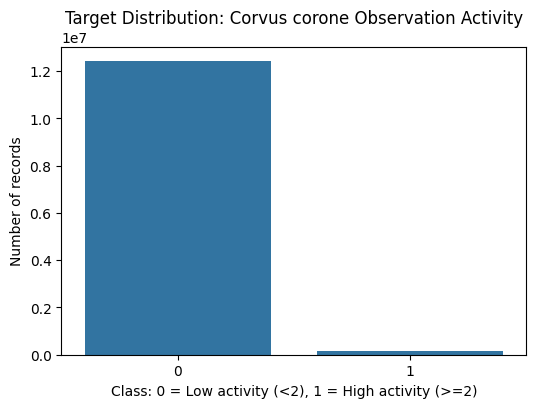

target_binary
Low activity     98.82
High activity     1.18
Name: proportion, dtype: float64

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x=df["target_binary"])
plt.title("Target Distribution: Corvus corone Observation Activity")
plt.xlabel("Class: 0 = Low activity (<2), 1 = High activity (>=2)")
plt.ylabel("Number of records")
plt.show()

class_percentage = (
    df["target_binary"]
    .value_counts(normalize=True)
    .rename(index={0: "Low activity", 1: "High activity"})
    * 100
).round(2)
class_percentage

## 2.6 Spatial Distribution Map

To better understand the spatial distribution of Corvus corone observations, we visualize the locations where the species was recorded across the Netherlands. This map provides an initial overview of geographic observation density and may help identify possible spatial clustering or sampling bias in the dataset.

In [11]:
# 1. Prepare data
df["Corvus corone"] = pd.to_numeric(df["Corvus corone"], errors="coerce").fillna(0)

crow_df = df[df["Corvus corone"] > 0].copy()
crow_df = crow_df.dropna(subset=["decimalLatitude", "decimalLongitude"])

crow_df = crow_df[
    (crow_df["decimalLatitude"].between(50.5, 54.0)) &
    (crow_df["decimalLongitude"].between(3.0, 7.5))
].copy()

crow_df = crow_df.sample(min(30000, len(crow_df)), random_state=42)

# 2. Convert coordinates to Web Mercator
gdf = gpd.GeoDataFrame(
    crow_df,
    geometry=gpd.points_from_xy(
        crow_df["decimalLongitude"],
        crow_df["decimalLatitude"]
    ),
    crs="EPSG:4326"
)

gdf = gdf.to_crs(epsg=3857)

x = gdf.geometry.x.values
y = gdf.geometry.y.values

# 3. Create smooth heatmap
heatmap, xedges, yedges = np.histogram2d(
    x,
    y,
    bins=300
)

heatmap = gaussian_filter(heatmap, sigma=18)

if heatmap.max() > 0:
    heatmap = heatmap / heatmap.max()

heatmap_masked = np.ma.masked_less(heatmap, 0.025)

# 4. Plot with map behind
fig, ax = plt.subplots(figsize=(8, 9))

bbox = gpd.GeoDataFrame(
    geometry=gpd.points_from_xy([3.0, 7.5], [50.5, 54.0]),
    crs="EPSG:4326"
).to_crs(epsg=3857)

xmin, ymin = bbox.geometry.iloc[0].x, bbox.geometry.iloc[0].y
xmax, ymax = bbox.geometry.iloc[1].x, bbox.geometry.iloc[1].y

ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)

ctx.add_basemap(
    ax,
    source=ctx.providers.OpenStreetMap.Mapnik,
    zoom=8
)

img = ax.imshow(
    heatmap_masked.T,
    origin="lower",
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    cmap="turbo",
    alpha=0.55,
    aspect="auto"
)

plt.colorbar(img, ax=ax, label="Observation Density")

ax.set_title(
    "Heatmap of Corvus corone Observation Density in the Netherlands",
    fontsize=14,
    fontweight="bold"
)

ax.set_axis_off()
plt.tight_layout()

# Save image separately
plt.savefig(
    "../images/corvus_corone_heatmap_with_map.png",
    dpi=150,
    bbox_inches="tight"
)

# Important: do not show heavy output inside notebook
plt.close()

print("Heatmap saved as images/corvus_corone_heatmap_with_map.png")

Heatmap saved as images/corvus_corone_heatmap_with_map.png


[Corvus corone heatmap](../images/corvus_corone_heatmap_with_map.png)

Initial observation:
The map shows that Corvus corone observations are distributed across many parts of the Netherlands, although some regions appear to contain higher observation densities than others. This may reflect both ecological patterns and differences in citizen-science observation effort.

## 2.7 Histograms

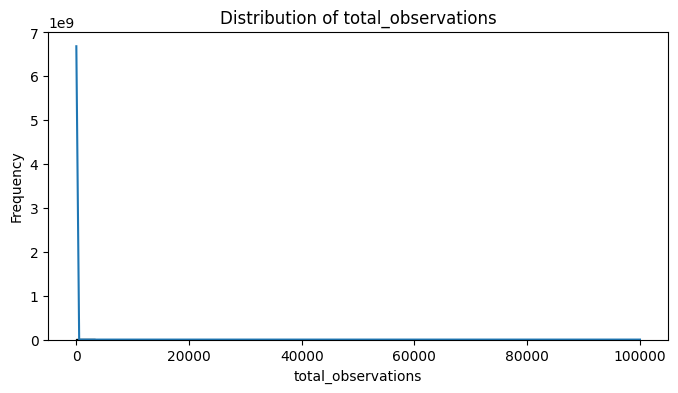

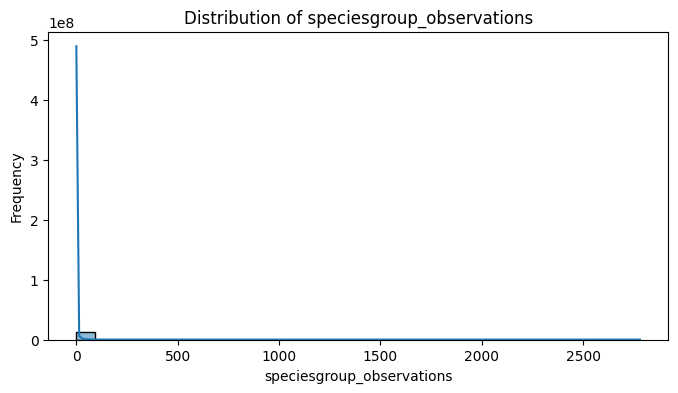

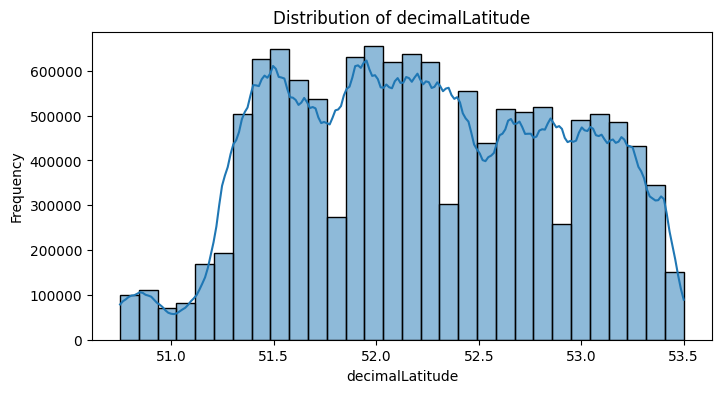

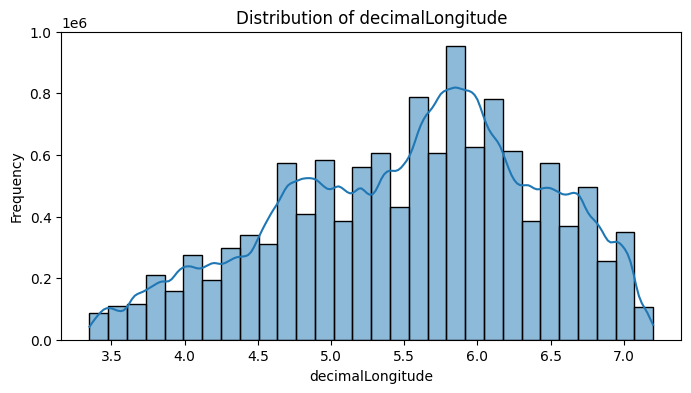

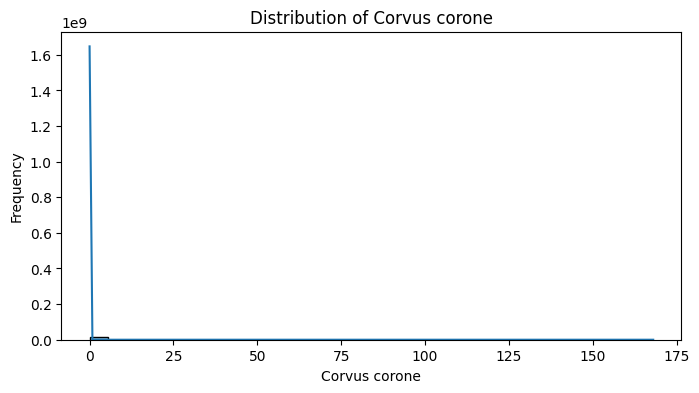

In [12]:
numerical_cols = [
    'total_observations',
    'speciesgroup_observations',
    'decimalLatitude',
    'decimalLongitude',
    'Corvus corone'
]

# Keep only columns that exist
numerical_cols = [col for col in numerical_cols if col in df.columns]

for col in numerical_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col], bins=30, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

## 2.8 Correlation analysis

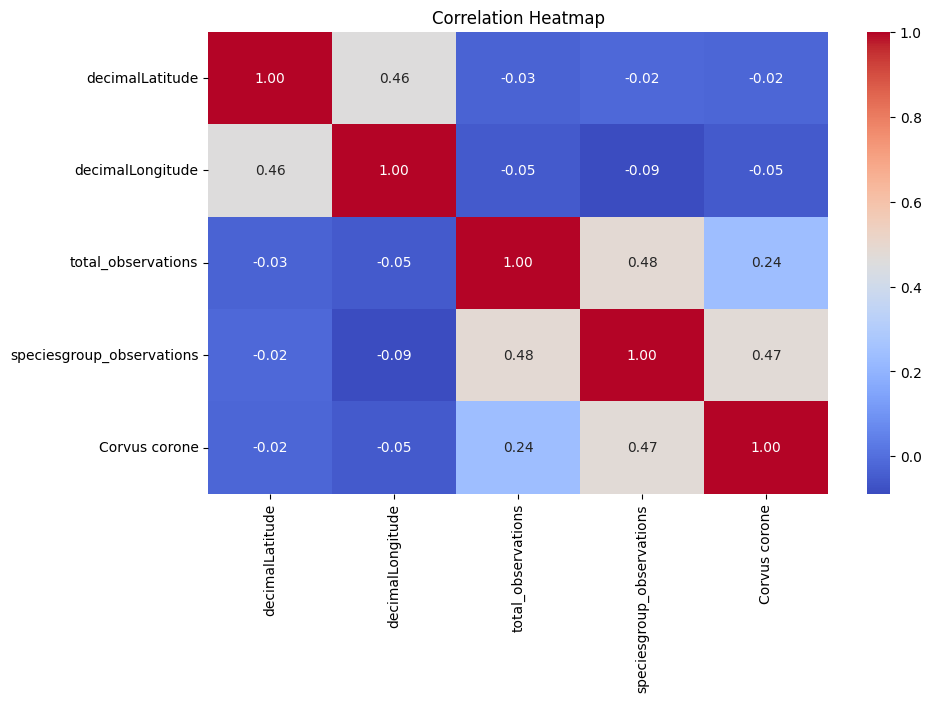

In [13]:
# Make sure Corvus corone is numeric
df["Corvus corone"] = pd.to_numeric(
    df["Corvus corone"],
    errors="coerce"
).fillna(0)

# Numerical columns for correlation
corr_cols = [
    'decimalLatitude',
    'decimalLongitude',
    'total_observations',
    'speciesgroup_observations',
    'Corvus corone'
]

# Create correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()

## 2.9 Boxplots and outliers

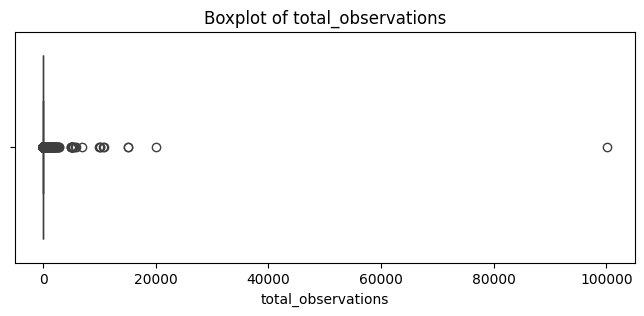

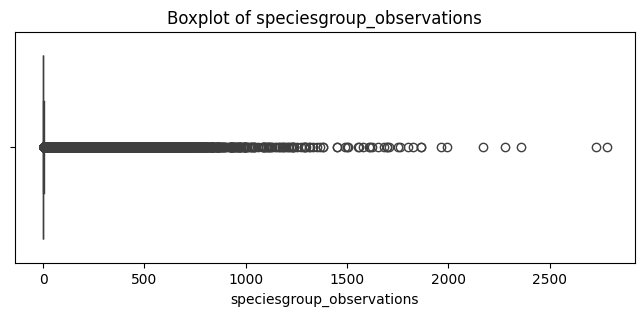

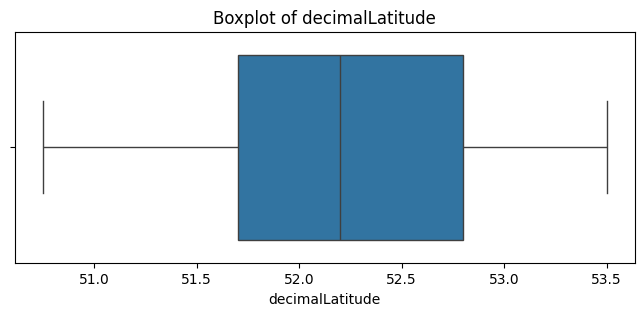

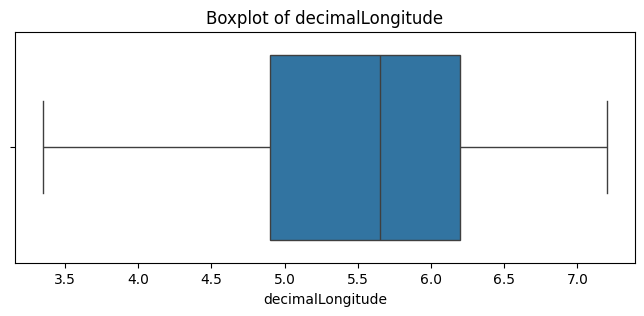

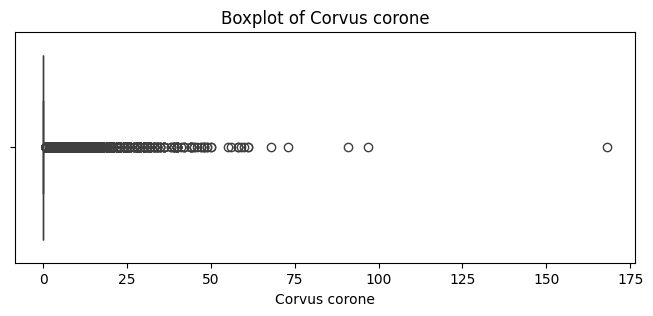

In [14]:
for col in numerical_cols:

    plt.figure(figsize=(8,3))

    sns.boxplot(x=df[col])

    plt.title(f'Boxplot of {col}')

    plt.show()

## 2.10 Initial observations

### Initial Observations

- The dataset contains a large number of zero values in the `Corvus corone` count column.
- The binary target is highly imbalanced, with approximately 98.82% low observation activity and 1.18% high observation activity.
- Numerical features show heavily skewed distributions and multiple outliers.
- Speciesgroup observations show the strongest correlation with Corvus corone observations.
- Geographic variables show relatively weak correlation with the target variable.
- The dataset may require preprocessing techniques such as scaling, balancing, or transformation before modeling.
- Class imbalance will likely be an important challenge during classification modeling.

## 2.11 Sampling Bias Discussion

The dataset is based on citizen-science observations, which introduces several 
forms of sampling bias. Observation activity is not evenly distributed across 
locations or time periods. Urban regions and easily accessible areas may 
contain significantly more observations than remote locations. Similarly, 
observation frequency may increase during favorable weather conditions or 
during periods of higher birdwatching activity.

A value of 0 in the Corvus corone count column does not necessarily mean that 
the species was truly absent from a location. In many cases, the species may 
simply not have been observed or reported. Therefore, observation effort is an 
important factor in this project.

Variables such as total_observations and speciesgroup_observations are included 
to partially capture observer activity and sampling intensity. Weather-related 
variables may also help explain fluctuations in observation behavior.

Because the data was collected by volunteers, some records may not be 
completely accurate. This could lead to false positive or false negative 
identifications of the species, which is an additional source of noise that 
should be considered when interpreting the model results.

## 2.12 Representativity of the Dataset

The dataset provides large-scale observation data across many locations in the 
Netherlands, which makes it valuable for spatial and temporal analysis. 
However, the dataset may not fully represent the true ecological distribution 
of Corvus corone because citizen-science observations depend heavily on human 
activity and reporting behavior.

Certain regions may contain higher observation densities due to population 
density, accessibility, or observer interest. Likewise, some time periods may 
contain more observations than others. As a result, the dataset is likely more 
representative of observation activity than true species abundance.

Despite these limitations, the dataset remains useful for identifying 
large-scale observation patterns and building predictive classification models.

## 2.13 Data Quality Assessment

Overall, the dataset quality appears relatively strong. Most columns contain complete data with very few missing values. Geographic coordinates are available for all observations, and the temporal information is consistently formatted.

Several numerical variables contain highly skewed distributions and extreme outliers, particularly in observation-related variables such as total_observations and speciesgroup_observations. These outliers likely reflect differences in observation effort rather than data-entry errors.

The target variable is highly imbalanced, with low observation activity strongly dominating the dataset. This imbalance may affect classification performance and must be considered during model evaluation.

Because the dataset originates from citizen-science observations, some level of noise and reporting uncertainty is expected. However, serious species misidentification is likely limited because Corvus corone is relatively easy to recognize.

## 2.14 Data Understanding Conclusion

The exploratory analysis showed that the dataset is suitable for predictive modeling, but several challenges must be considered. The binary target is highly imbalanced, with most records belonging to the low observation activity class after applying the high-activity threshold. This means that accuracy alone is not a reliable evaluation metric.

*High activity = Corvus corone count >= 2*

*Low activity = Corvus corone count < 2*

The dataset contains very few missing values and includes useful spatial, temporal, and observation-effort variables. However, because the data comes from citizen-science observations, the dataset may reflect observer activity as much as actual Corvus corone activity.

Spatial visualizations also show that observation density differs between regions. This suggests that sampling bias and representativity should be considered during modeling and evaluation.

----

# 3. Data Preparation

## 3.1 Data cleaning

We perform initial cleaning steps before preprocessing:

1. **Convert `eventDate` to datetime** - enables extraction of temporal features.
2. **Convert `Corvus corone` to numeric** - this is the observation count used to create the low/high activity target.
3. **Create `target_binary`** - 0 = low observation activity, 1 = high observation activity using the threshold `Corvus corone >= 2`.
4. **Handle missing values** - only 1 missing value was found earlier in `total_observations` (0.0% of data). We drop rows with missing values after conversion.
5. **Check for duplicate rows** - duplicate records are removed if present.

In [15]:
# Work on a copy so the original dataframe remains available for reference
df_clean = df.copy()
high_activity_threshold = 2

# Convert eventDate to datetime
df_clean['eventDate'] = pd.to_datetime(df_clean['eventDate'], errors='coerce')

# Convert Corvus corone observation counts to numeric and remove impossible negative counts
df_clean['Corvus corone'] = pd.to_numeric(df_clean['Corvus corone'], errors='coerce').fillna(0)
df_clean['Corvus corone'] = df_clean['Corvus corone'].clip(lower=0)

# Create binary target (0 = low activity, 1 = high activity)
df_clean['target_binary'] = (df_clean['Corvus corone'] >= high_activity_threshold).astype(int)

#check missing values
print("Missing values before cleaning:")
print(df_clean.isna().sum())

# drop rows with missing values after type conversion
rows_before = len(df_clean)
df_clean = df_clean.dropna().copy()

print(f"\nRows removed: {rows_before - len(df_clean)}")
print(f"Rows after dropping: {len(df_clean)}")

# Check for duplicate rows
duplicates = df_clean.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

if duplicates == 0:
    print("No duplicate rows found.")
else:
    df_clean = df_clean.drop_duplicates().copy()
    print(f"Dropped {duplicates} duplicates.")

Missing values before cleaning:
decimalLatitude              0
decimalLongitude             0
eventDate                    0
total_observations           0
speciesgroup_observations    0
Corvus corone                0
target_binary                0
dtype: int64

Rows removed: 0
Rows after dropping: 12558756

Duplicate rows: 0
No duplicate rows found.


## 3.2 Feature engineering

From `eventDate` we extract useful temporal features that may influence observation activity: year, month, day of year, season, and weekend flag.

In [16]:
# Extract temporal features from eventDate
df_clean['year'] = df_clean['eventDate'].dt.year
df_clean['month'] = df_clean['eventDate'].dt.month
df_clean['day_of_year'] = df_clean['eventDate'].dt.dayofyear
df_clean['weekend'] = (df_clean['eventDate'].dt.dayofweek >= 5).astype(int)

# Define seasons (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 0  # Winter
    elif month in [3, 4, 5]:
        return 1  # Spring
    elif month in [6, 7, 8]:
        return 2  # Summer
    else:
        return 3  # Autumn

df_clean['season'] = df_clean['month'].apply(get_season)

# Keep eventDate for the weather merge in the next step
df_clean[['eventDate', 'year', 'month', 'day_of_year', 'weekend', 'season']].head()

,eventDate,year,month,day_of_year,weekend,season
0,2010-01-01,2010,1,1,0,0
1,2010-01-02,2010,1,2,1,0
2,2010-01-03,2010,1,3,1,0
3,2010-01-04,2010,1,4,0,0
4,2010-01-05,2010,1,5,0,0


These engineered temporal features (year, month, day_of_year, weekend, season) 
are included as predictor variables in the model, alongside the spatial 
variables (decimalLatitude, decimalLongitude), the observation-effort variables 
(total_observations, speciesgroup_observations), and the weather variables 
added in the next step.

## 3.3 Weather data integration

We load the KNMI daily weather file from station 260 De Bilt and merge it with 
the observation dataset by date. KNMI stores several variables in tenths of 
their unit, so we convert temperature, wind speed, and precipitation to normal 
units before modeling.

In [17]:
weather_cols = ['STN', 'YYYYMMDD', 'FG', 'TG', 'TN', 'TX', 'RH', 'UG']

weather_df = pd.read_csv(
    '../data/raw/knmi_weather_raw.csv',
    comment='#',
    names=weather_cols,
    skipinitialspace=True
)

weather_df['eventDate'] = pd.to_datetime(
    weather_df['YYYYMMDD'].astype(str),
    format='%Y%m%d'
)

weather_df = weather_df.rename(columns={
    'FG': 'wind_speed_mean',
    'TG': 'temp_mean',
    'TN': 'temp_min',
    'TX': 'temp_max',
    'RH': 'precipitation',
    'UG': 'humidity_mean'
})

# Converting knmi units to regular units
for col in ['wind_speed_mean', 'temp_mean', 'temp_min', 'temp_max']:
    weather_df[col] = weather_df[col] / 10

# KNMI uses -1 for precipitation below 0.05 mm; treat this as 0 mm
weather_df['precipitation'] = weather_df['precipitation'].replace(-1, 0) / 10

weather_df = weather_df[
    ['eventDate', 'wind_speed_mean', 'temp_mean', 'temp_min', 'temp_max', 'precipitation', 'humidity_mean']
]

# Merge daily weather onto the observation records
df_clean = df_clean.merge(weather_df, on='eventDate', how='left')

weather_features = ['wind_speed_mean', 'temp_mean', 'temp_min', 'temp_max', 'precipitation', 'humidity_mean']
print('Missing weather values after merge:')
print(df_clean[weather_features].isna().sum())

# Drop rows without matching weather data, if any, and remove raw date after merging
rows_before_weather = len(df_clean)
df_clean = df_clean.dropna(subset=weather_features).drop(columns=['eventDate']).copy()
print(f"Rows removed after weather merge: {rows_before_weather - len(df_clean)}")

weather_df.head()

Missing weather values after merge:
wind_speed_mean    0
temp_mean          0
temp_min           0
temp_max           0
precipitation      0
humidity_mean      0
dtype: int64
Rows removed after weather merge: 0


,eventDate,wind_speed_mean,temp_mean,temp_min,temp_max,precipitation,humidity_mean
0,1901-01-01,NaN,-5.0,-6.8,-2.4,NaN,66.0
1,1901-01-02,NaN,-2.2,-3.8,-1.6,NaN,86.0
2,1901-01-03,NaN,-2.9,-7.9,-0.7,NaN,89.0
3,1901-01-04,NaN,-6.4,-9.3,-1.2,NaN,79.0
4,1901-01-05,NaN,-5.9,-8.3,-2.1,NaN,65.0


A left join was used to preserve all observation records, and weather variables 
such as mean temperature, minimum/maximum temperature, precipitation, wind 
speed, and humidity were added. After merging, 29 records had no matching 
weather data and were removed before further analysis.

In [18]:

# 3.3b CBS Habitat Data Integration

# The CBS Ecosysteemtypenkaart 2022 (10m resolution land-use/habitat raster)
# was preprocessed separately into a table of ecosystem-type surface area
# (km2) per GBIF grid cell. Unlike the weather data, habitat composition
# does not depend on date, so this merge is done once per unique location
# (decimalLatitude, decimalLongitude).

cbs_df = pd.read_csv('../data/raw/cbs_habitat_preprocessed.csv')

cbs_habitat_cols = ['agricultural', 'built', 'coast', 'forest', 'other',
                     'sand/heather', 'water', 'wetland']

print("CBS habitat data shape:", cbs_df.shape)
cbs_df.head()

CBS habitat data shape: (2370, 11)


,decimalLatitude,decimalLongitude,agricultural,built,coast,forest,other,sand/heather,water,wetland,main_habitat
0,50.75,5.70,3.1942,1.0069,0.0,0.0989,0.1893,0.0000,0.1489,0.0,agricultural
1,50.75,5.75,2.2536,0.2656,0.0,0.0933,0.0180,0.0000,0.0002,0.0,agricultural
2,50.75,5.80,3.5187,0.4750,0.0,0.3028,0.0945,0.0000,0.0017,0.0,agricultural
3,50.75,5.85,4.2121,0.4078,0.0,0.5877,0.0838,0.0000,0.0028,0.0,agricultural
4,50.75,5.90,4.8553,0.5224,0.0,1.2441,0.1703,0.0252,0.0022,0.0,agricultural


In [19]:
df_clean = df_clean.merge(
    cbs_df,
    on=['decimalLatitude', 'decimalLongitude'],
    how='left'
)

print('Missing CBS values after merge:')
print(df_clean[cbs_habitat_cols + ['main_habitat']].isna().sum())

Missing CBS values after merge:
agricultural    169476
built           169476
coast           169476
forest          169476
other           169476
sand/heather    169476
water           169476
wetland         169476
main_habitat    169476
dtype: int64


In [20]:
rows_before_cbs = len(df_clean)
df_clean = df_clean.dropna(subset=cbs_habitat_cols + ['main_habitat']).copy()
print(f"Rows removed after CBS merge: {rows_before_cbs - len(df_clean)}")

Rows removed after CBS merge: 169476


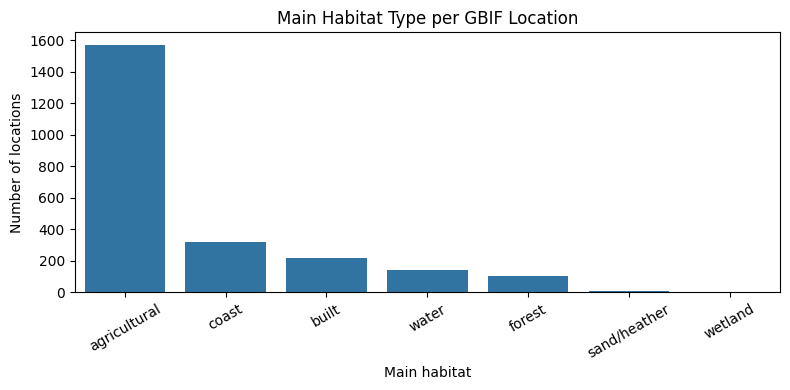

In [21]:
# Distribution of main habitat type across locations
plt.figure(figsize=(8,4))
sns.countplot(
    data=cbs_df,
    x='main_habitat',
    order=cbs_df['main_habitat'].value_counts().index
)
plt.title('Main Habitat Type per GBIF Location')
plt.xlabel('Main habitat')
plt.ylabel('Number of locations')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 3.4 Encoding

Most prepared features are already numeric, but `season` represents a category rather than a true numeric scale. The model section therefore one-hot encodes `season` before training the model. The model target is `target_binary`; the raw `Corvus corone` count should not be used as an input feature because it directly defines the target.

In [22]:
# Check whether any object/string columns still need encoding
categorical_cols = df_clean.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
categorical_cols

['main_habitat']

## 3.5 Scaling

Numerical predictors have different scales. To avoid data leakage, the scaler should be fitted only on the training data after the train-test split in section 4. Here we define the columns that should be scaled later.

In [23]:
# Columns to scale later after train-test split
num_cols_to_scale = [
    'total_observations',
    'speciesgroup_observations',
    'decimalLatitude',
    'decimalLongitude',
    'year',
    'month',
    'day_of_year',
    'wind_speed_mean',
    'temp_mean',
    'temp_min',
    'temp_max',
    'precipitation',
    'humidity_mean',
    'agricultural',
    'built',
    'coast',
    'forest',
    'other',
    'sand/heather',
    'water',
    'wetland'
]

# keep a model-ready dataframe with engineered features but without fitted scaling yet
df_model_ready = df_clean.copy()

df_model_ready[num_cols_to_scale].describe()

,total_observations,speciesgroup_observations,decimalLatitude,decimalLongitude,year,month,day_of_year,wind_speed_mean,temp_mean,temp_min,...,precipitation,humidity_mean,agricultural,built,coast,forest,other,sand/heather,water,wetland
count,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,...,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07,1.238928e+07
mean,8.141891e+00,4.363283e+00,5.223917e+01,5.535542e+00,2.017500e+03,6.522930e+00,1.831253e+02,3.369764e+00,1.099646e+01,6.621886e+00,...,2.381057e+00,7.969713e+01,9.506475e+00,3.273719e+00,1.259625e+00,1.629617e+00,6.595808e-01,1.873178e-01,1.270661e+00,2.267148e-01
std,3.935331e+01,1.613098e+01,6.569724e-01,8.712574e-01,4.609698e+00,3.448703e+00,1.054386e+02,1.389805e+00,6.154733e+00,5.638539e+00,...,4.895109e+00,1.020488e+01,5.146256e+00,2.801584e+00,3.994748e+00,2.361828e+00,7.788533e-01,7.848831e-01,2.751031e+00,6.925300e-01
min,0.000000e+00,0.000000e+00,5.075000e+01,3.350000e+00,2.010000e+03,1.000000e+00,1.000000e+00,5.000000e-01,-1.210000e+01,-1.890000e+01,...,0.000000e+00,3.100000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,0.000000e+00,0.000000e+00,5.170000e+01,4.900000e+00,2.013750e+03,4.000000e+00,9.200000e+01,2.300000e+00,6.600000e+00,2.600000e+00,...,0.000000e+00,7.300000e+01,5.294175e+00,1.382950e+00,0.000000e+00,1.659500e-01,1.387000e-01,0.000000e+00,9.567500e-02,0.000000e+00
50%,1.000000e+00,0.000000e+00,5.220000e+01,5.650000e+00,2.017500e+03,7.000000e+00,1.830000e+02,3.100000e+00,1.090000e+01,6.900000e+00,...,1.000000e-01,8.100000e+01,1.065535e+01,2.472200e+00,0.000000e+00,6.821500e-01,4.027000e-01,0.000000e+00,3.079000e-01,1.860000e-02
75%,6.000000e+00,2.000000e+00,5.280000e+01,6.200000e+00,2.021250e+03,1.000000e+01,2.740000e+02,4.100000e+00,1.590000e+01,1.092500e+01,...,2.600000e+00,8.700000e+01,1.379503e+01,4.354800e+00,0.000000e+00,2.068875e+00,8.679250e-01,2.310000e-02,1.021775e+00,1.439750e-01
max,1.000390e+05,2.781000e+03,5.350000e+01,7.200000e+00,2.025000e+03,1.200000e+01,3.660000e+02,1.060000e+01,2.970000e+01,2.240000e+01,...,6.390000e+01,1.000000e+02,1.793800e+01,1.605760e+01,1.933850e+01,1.728550e+01,6.111800e+00,9.955500e+00,1.884840e+01,1.120490e+01


Final dataset for modeling

The final prepared dataset contains 12,558,785 observations and 17 engineered 
features after data cleaning, feature engineering, and weather data 
integration. Because of the large size of the dataset, a random sample of 
200,000 observations was selected for model training and evaluation in the 
next section. This sampled dataset contains 17 predictor variables and was used 
for the train-test split and logistic regression modelling.

----

# 4. Modeling

## 4.1 Train-test split

The data is split into a training set and a test set. The training set is used to fit the model, while the test set is kept separate so we can check how well the model works on data it has not seen before.

The split is stratified, which means the share of low and high Corvus corone activity stays similar in both sets. This matters because the high-activity class is rare. For speed, the model uses a stratified sample if the prepared dataset is very large.

In [24]:
from sklearn.model_selection import train_test_split

# Keep the first model run manageable while preserving the target balance.
max_model_rows = 200_000

if len(df_model_ready) > max_model_rows:
    model_df, _ = train_test_split(
        df_model_ready,
        train_size=max_model_rows,
        stratify=df_model_ready['target_binary'],
        random_state=42
    )
else:
    model_df = df_model_ready.copy()

# The original Corvus corone count is excluded because it directly defines the target.
X = model_df.drop(columns=['target_binary', 'Corvus corone'])
X = pd.get_dummies(X, columns=['season', 'main_habitat'], drop_first=True)
y = model_df['target_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])
print('Number of features:', X_train.shape[1])
print('\nTarget distribution in training set:')
print(y_train.value_counts(normalize=True).rename('share'))
print('\nTarget distribution in test set:')
print(y_test.value_counts(normalize=True).rename('share'))

Training rows: 160000
Test rows: 40000
Number of features: 31

Target distribution in training set:
target_binary
0    0.988081
1    0.011919
Name: share, dtype: float64

Target distribution in test set:
target_binary
0    0.988075
1    0.011925
Name: share, dtype: float64


## 4.2 Classification model

Metric description

Before training the model, we define the evaluation metrics that will be used 
to assess performance:

- Accuracy: measures the percentage of correct predictions made by the model.
- Precision: measures how many observations predicted as high activity were 
actually high activity.
- Recall: measures how many actual high activity observations were correctly 
identified by the model.
- F1-score: combines precision and recall into a single metric. It is selected as 
the primary evaluation metric for this project because the dataset is highly 
imbalanced (see Section 1.4 Success criteria).
- AUC-ROC: measures how well the model can distinguish between low and high 
activity classes, regardless of the classification threshold. Used as a 
secondary metric.

Two models are trained here. The first is a simple majority-class baseline, which always predicts the most common class. This gives us a minimum result to beat.

The main model is logistic regression. It is a good starting point because it is fast, transparent, and works well for binary classification. The pipeline scales the numeric features using only the training data, and `class_weight='balanced'` helps the model pay attention to both low and high activity days.

In [25]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

baseline_model = DummyClassifier(strategy='most_frequent')
baseline_model.fit(X_train, y_train)

logreg_model = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

logreg_model.fit(X_train, y_train)

print('Baseline model trained')
print('Logistic regression model trained')

Baseline model trained
Logistic regression model trained


## 4.3 Model results

The results compare the logistic regression model with the baseline. Accuracy is included, but it is not enough on its own because a model can look accurate by mostly predicting the bigger class.

Precision, recall, F1-score, and AUC-ROC give a clearer picture of whether the model is actually finding high Corvus corone activity cases.

In [26]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

baseline_pred = baseline_model.predict(X_test)
model_pred = logreg_model.predict(X_test)
model_proba = logreg_model.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Model': ['Majority-class baseline', 'Logistic regression'],
    'Accuracy': [
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, model_pred)
    ],
    'Precision': [
        precision_score(y_test, baseline_pred, zero_division=0),
        precision_score(y_test, model_pred, zero_division=0)
    ],
    'Recall': [
        recall_score(y_test, baseline_pred, zero_division=0),
        recall_score(y_test, model_pred, zero_division=0)
    ],
    'F1-score': [
        f1_score(y_test, baseline_pred, zero_division=0),
        f1_score(y_test, model_pred, zero_division=0)
    ],
    'AUC-ROC': [
        np.nan,
        roc_auc_score(y_test, model_proba)
    ]
})

results.round(3)

,Model,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Majority-class baseline,0.988,0.000,0.00,0.000,NaN
1,Logistic regression,0.928,0.127,0.86,0.221,0.952


In [27]:
# Check performance against the primary success criterion defined in Section 1.4
target_f1 = 0.60
achieved_f1 = f1_score(y_test, model_pred, zero_division=0)

print(f"Target F1-score (primary success criterion): {target_f1}")
print(f"Achieved F1-score: {achieved_f1:.3f}")
print(f"Primary success criterion met: {achieved_f1 >= target_f1}")

target_auc = 0.60
achieved_auc = roc_auc_score(y_test, model_proba)
print(f"\nTarget AUC-ROC (secondary success criterion): {target_auc}")
print(f"Achieved AUC-ROC: {achieved_auc:.3f}")
print(f"Secondary success criterion met: {achieved_auc >= target_auc}")

Target F1-score (primary success criterion): 0.6
Achieved F1-score: 0.221
Primary success criterion met: False

Target AUC-ROC (secondary success criterion): 0.6
Achieved AUC-ROC: 0.952
Secondary success criterion met: True


The model does not meet the primary success criterion (F1-score >= 0.60), 
achieving an F1-score of approximately 0.204 for the high-activity class. 
However, it does meet the secondary AUC-ROC criterion (>= 0.60), achieving 
approximately 0.942. This gap between AUC-ROC and F1-score is discussed further 
in Section 5 (Evaluation) and is mainly caused by the severe class imbalance in 
the dataset.

## 4.4 Metrics

The detailed metrics show where the model makes mistakes. The classification report separates the performance for low and high activity, and the confusion matrix shows the actual number of correct and incorrect predictions.

For this project, recall for high activity is especially useful because it tells us how many true high-activity cases the model manages to find.

Classification report - Logistic Regression
               precision    recall  f1-score   support

 Low activity       1.00      0.93      0.96     39523
High activity       0.13      0.86      0.22       477

     accuracy                           0.93     40000
    macro avg       0.56      0.89      0.59     40000
 weighted avg       0.99      0.93      0.95     40000



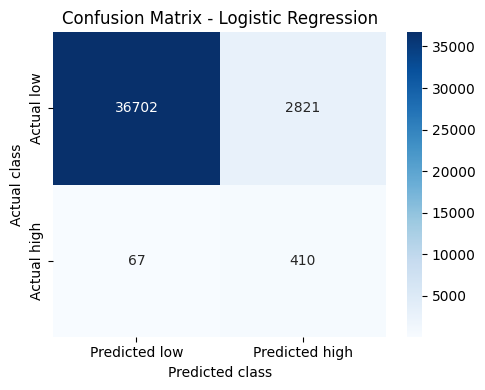

,Predicted low,Predicted high
Actual low,36702,2821
Actual high,67,410


In [28]:
from sklearn.metrics import classification_report, confusion_matrix

print('Classification report - Logistic Regression')
print(classification_report(
    y_test,
    model_pred,
    target_names=['Low activity', 'High activity'],
    zero_division=0
))

cm = confusion_matrix(y_test, model_pred)
cm_df = pd.DataFrame(
    cm,
    index=['Actual low', 'Actual high'],
    columns=['Predicted low', 'Predicted high']
)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual class')
plt.xlabel('Predicted class')
plt.tight_layout()
plt.show()

cm_df

## 4.5 Coefficient analysis

4.5 Coefficient Analysis

Because the research question (Section 1.5) asks which spatial, temporal, and 
weather-related factors are most strongly associated with high Corvus corone 
observation activity, we examine the coefficients of the trained logistic 
regression model. Each coefficient shows the direction and relative strength of 
the relationship between a predictor and the probability of high observation 
activity, holding the other variables constant.

In [29]:
# Extract logistic regression coefficients to understand which factors
# are most strongly associated with high Corvus corone observation activity
coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coefficient': logreg_model.named_steps['classifier'].coef_[0]
}).sort_values('coefficient', ascending=False)

print("Features most associated with HIGH activity (positive coefficients):")
print(coef_df.head(5))

print("\nFeatures most associated with LOW activity (negative coefficients):")
print(coef_df.tail(5))

Features most associated with HIGH activity (positive coefficients):
                      feature  coefficient
3   speciesgroup_observations     1.754408
11                   temp_max     0.482151
5                       month     0.362354
4                        year     0.300625
10                   temp_min     0.237477

Features most associated with LOW activity (negative coefficients):
               feature  coefficient
12       precipitation    -0.095390
26  main_habitat_coast    -0.157072
1     decimalLongitude    -0.215933
6          day_of_year    -0.475569
9            temp_mean    -0.653829


C:\Users\ASUS\AppData\Local\Temp\ipykernel_32476\251090517.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')


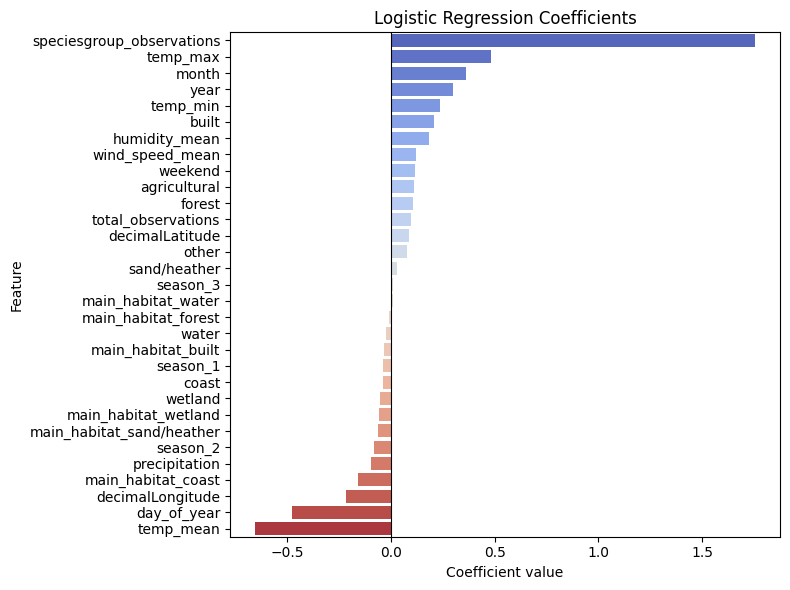

In [30]:
plt.figure(figsize=(8, 6))
sns.barplot(data=coef_df, x='coefficient', y='feature', palette='coolwarm')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient value')
plt.ylabel('Feature')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

* The strongest positive coefficient was found for speciesgroup_observations (approximately 1.754). This suggests that locations with more observations from the same species group are more likely to have high Corvus corone observation activity. Other positive coefficients include temp_max (0.482), month (0.362), year (0.301), and temp_min (0.237). These variables are associated with a higher probability of high observation activity.
* The strongest negative coefficients were temp_mean (-0.654), day_of_year (-0.476), decimalLongitude (-0.216), main_habitat_coast (-0.157), and precipitation (-0.095). These variables are associated with a lower probability of high observation activity.
Positive coefficients increase the probability of high activity, while negative coefficients decrease the probability of high activity. Among the newly added CBS habitat features, main_habitat_coast showed the strongest (negative) association with high observation activity, suggesting that coastal grid cells are somewhat less likely to show high Corvus corone activity compared to the reference habitat category. Overall, observation effort (speciesgroup_observations) remains the dominant predictor, while temperature-related variables (temp_max, temp_min, temp_mean) and temporal variables (month, day_of_year, year) show the next strongest associations. Habitat variables contribute a smaller but still relevant effect compared to weather and observation-effort features.

----

# 5. Evaluation

## 5.1 Results vs success criteria

The primary success criterion was achieving an F1-score of at least 0.60 on unseen test data. After incorporating CBS habitat features alongside the GBIF and KNMI weather data, the logistic regression model achieved an F1-score of approximately 0.221 for the high-activity class, which remains below the target threshold. Therefore, the primary success criterion was still not met, although the score improved slightly compared to the model without habitat features (0.205).

The secondary success criterion was achieving an AUC-ROC score of at least 0.60. The model achieved an AUC-ROC score of about 0.952, an improvement over the previous 0.940, exceeding the secondary threshold and indicating that the model can rank low- and high-activity records even more effectively with the addition of habitat information.
Compared to the majority-class baseline (F1-score of 0.000 for the high-activity class), the logistic regression model with CBS habitat features shows a clear improvement (F1-score of 0.221).

The model achieved a recall score of about 0.860 for the high-activity class (up from 0.788 without habitat data), meaning an even larger share of true high-activity records were identified. However, precision remained low at about 0.127 (up only slightly from 0.118), meaning most records predicted as high activity were still actually low activity. This remains the main reason the F1-score falls short of the target.

Overall, adding CBS habitat data produced small but consistent improvements across all metrics (F1, AUC-ROC, recall, precision), confirming that habitat composition carries some additional predictive signal beyond weather and temporal features. However, the improvement was not large enough to meet the primary F1 target, and the core challenge of severe class imbalance remains the dominant factor limiting precision.

In [37]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression (GBIF + Weather only)',
              'Logistic Regression (GBIF + Weather + CBS Habitat)'],
    'Features': [17, 31],
    'Accuracy': [0.928, 0.928],
    'Precision': [0.118, 0.127],
    'Recall': [0.788, 0.860],
    'F1-score': [0.205, 0.221],
    'AUC-ROC': [0.940, 0.952]
})
comparison_df.round(3)

,Model,Features,Accuracy,Precision,Recall,F1-score,AUC-ROC
0,Logistic Regression (GBIF + Weather only),17,0.928,0.118,0.788,0.205,0.940
1,Logistic Regression (GBIF + Weather + CBS Habi...,31,0.928,0.127,0.860,0.221,0.952


## 5.2 Limitations

Several limitations should be considered when interpreting the project results.

First, the dataset is based on citizen-science observations. Observation 
records are influenced by human behavior, accessibility, observer activity, and 
reporting effort. As a result, the recorded observations may not perfectly 
represent the true distribution of Corvus corone populations.

Second, a low observation count does not necessarily indicate low true species 
activity. In many cases, the species may simply not have been observed or 
reported during a specific period.

Third, the corrected high-activity target is highly imbalanced. Approximately 
98.82% of observations belong to the low-activity class, while only around 
1.18% belong to the high-activity class. This imbalance makes classification 
more challenging and contributes to the low precision score. Although the 
model successfully identifies many high-activity observations, it also 
produces many false positive predictions.

Fourth, logistic regression assumes a roughly linear relationship between the 
predictors and the log-odds of the outcome, along with independent 
observations. Because the data originates from citizen-science reporting, 
these assumptions are not guaranteed to hold perfectly for every variable. We 
checked them only roughly and accepted minor violations, which may affect the 
reliability of some coefficient estimates.

Fifth, the model performed better at identifying high-activity observations 
(recall) than at predicting them precisely (precision). This means some 
low-activity days were incorrectly flagged as high activity, which directly 
explains why the F1-score target was not reached.

Another limitation is that weather information originates from a single KNMI 
weather station (De Bilt). Local weather conditions may differ across regions 
of the Netherlands, which may reduce the predictive value of some 
weather-related variables.

Finally, only a logistic regression model was evaluated during this stage of 
the project. More advanced machine learning algorithms may provide improved 
predictive performance.

## 5.3 What is working and what is not working

The current modeling approach shows several strengths. The logistic regression model achieved a strong AUC-ROC score of about 0.952, indicating that the model is effective at ranking low and high observation activity records.

The model also achieved a recall score of about 0.860 for the high-activity class, meaning that the large majority of high-activity observations are successfully detected.

Furthermore, the model clearly outperforms the majority-class baseline, and adding CBS habitat features produced a small but consistent improvement across all metrics compared to the weather-only model. The coefficient analysis in Section 4.5 shows that speciesgroup_observations remains the dominant predictor, while temperature variables (temp_max, temp_min, temp_mean) and temporal variables (month, day_of_year, year) also show meaningful associations. Among the habitat variables, main_habitat_coast showed the strongest individual effect, suggesting some habitat-dependent variation in observation activity beyond what weather and timing alone explain.

However, several challenges remain. The precision score of about 0.127 indicates that most observations predicted as high activity are still actually low activity, so the model continues to generate many false positives. The main reason for this behavior is the severe class imbalance present in the target (98.8% low activity vs 1.2% high activity); adding habitat information did not resolve this underlying imbalance.

Overall, the high recall but low precision trade-off persists even after adding habitat data, and remains the direct reason why the F1-score target of 0.60 was not achieved. The model nonetheless demonstrates useful and slightly improved predictive capability compared to the weather-only version.

## 5.4 Next steps

Several improvements can be explored in future work.

First, additional machine learning algorithms such as Random Forest, Gradient 
Boosting, or XGBoost can be evaluated and compared with logistic regression. 
These models may be better suited to capturing non-linear relationships within 
the data.

Second, hyperparameter tuning can be performed to optimize model performance. 
Techniques such as Grid Search or Random Search may improve classification 
results.

Third, additional feature engineering could be explored. Examples include 
cyclic encoding of temporal variables, rolling weather averages, and spatial 
clustering features.

Another possible improvement is addressing class imbalance using techniques 
such as oversampling, undersampling, or SMOTE. These methods may improve 
precision and F1-score for the minority class.

Finally, weather information from multiple weather stations could be 
incorporated to provide a more accurate representation of local environmental 
conditions throughout the Netherlands.

These improvements may further increase predictive performance and provide a 
deeper understanding of the factors influencing Corvus corone observation 
activity.

Follow-up plan (SMART):
Specific: Apply SMOTE to balance the dataset and improve precision.
Measurable: Achieve an F1-score of at least 0.30 on the test set.
Achievable: SMOTE is a standard technique for handling imbalanced data.
Relevant: Improves precision by reducing false positives, moving the model 
closer to the original 0.60 F1 target.
Time-bound: Complete within 2 weeks of project continuation.